# Weather Data Prediction

In [5]:
import numpy as np 
import pandas as py
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
df=pd.read_csv("C:\\Users\\yuvra\\Downloads\\GlobalWeatherRepository-selected-columns.csv")
df.head()

,country,location_name,latitude,longitude,timezone,last_updated_epoch,last_updated,temperature_celsius,temperature_fahrenheit,condition_text
0,Afghanistan,Kabul,34.52,69.18,Asia/Kabul,1715849100,2024-05-16 13:15,26.6,79.8,Partly Cloudy
1,Albania,Tirana,41.33,19.82,Europe/Tirane,1715849100,2024-05-16 10:45,19.0,66.2,Partly cloudy
2,Algeria,Algiers,36.76,3.05,Africa/Algiers,1715849100,2024-05-16 09:45,23.0,73.4,Sunny
3,Andorra,Andorra La Vella,42.50,1.52,Europe/Andorra,1715849100,2024-05-16 10:45,6.3,43.3,Light drizzle
4,Angola,Luanda,-8.84,13.23,Africa/Luanda,1715849100,2024-05-16 09:45,26.0,78.8,Partly cloudy


In [10]:
df.shape

(167228, 10)

In [11]:
df.columns

Index(['country', 'location_name', 'latitude', 'longitude', 'timezone',
       'last_updated_epoch', 'last_updated', 'temperature_celsius',
       'temperature_fahrenheit', 'condition_text'],
      dtype='object')

In [12]:
df.isnull().sum()

country                   0
location_name             0
latitude                  0
longitude                 0
timezone                  0
last_updated_epoch        0
last_updated              0
temperature_celsius       0
temperature_fahrenheit    0
condition_text            0
dtype: int64

In [13]:
df.isna().sum()

country                   0
location_name             0
latitude                  0
longitude                 0
timezone                  0
last_updated_epoch        0
last_updated              0
temperature_celsius       0
temperature_fahrenheit    0
condition_text            0
dtype: int64

In [18]:
# Check data types and missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167228 entries, 0 to 167227
Data columns (total 10 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   country                 167228 non-null  object 
 1   location_name           167228 non-null  object 
 2   latitude                167228 non-null  float64
 3   longitude               167228 non-null  float64
 4   timezone                167228 non-null  object 
 5   last_updated_epoch      167228 non-null  int64  
 6   last_updated            167228 non-null  object 
 7   temperature_celsius     167228 non-null  float64
 8   temperature_fahrenheit  167228 non-null  float64
 9   condition_text          167228 non-null  object 
dtypes: float64(4), int64(1), object(5)
memory usage: 12.8+ MB


In [19]:
# Remove duplicate rows
df = df.drop_duplicates()

In [20]:
df.duplicated().sum()

0

In [21]:
# Remove rows with missing values
df = df.dropna()

# Check missing values again
df.isnull().sum()

country                   0
location_name             0
latitude                  0
longitude                 0
timezone                  0
last_updated_epoch        0
last_updated              0
temperature_celsius       0
temperature_fahrenheit    0
condition_text            0
dtype: int64

In [22]:
# Check duplicate rows after cleaning
df.duplicated().sum()

0

In [25]:
# Save cleaned data
df.to_csv("C:\\Users\\yuvra\\Downloads\\GlobalWeatherRepository-selected-columns.csv")

# Exploratory Data Analysis:

In [33]:
import pandas as pd
import matplotlib.pyplot as plt

# Load weather dataset
df = pd.read_csv(
    "C:\\Users\\yuvra\\Downloads\\GlobalWeatherRepository-selected-columns.csv"
)

# Remove extra spaces from column names
df.columns = df.columns.str.strip()

# Check columns
print(df.columns.tolist())

# Display first 5 rows
df.head()

['Unnamed: 0', 'country', 'location_name', 'latitude', 'longitude', 'timezone', 'last_updated_epoch', 'last_updated', 'temperature_celsius', 'temperature_fahrenheit', 'condition_text']


,Unnamed: 0,country,location_name,latitude,longitude,timezone,last_updated_epoch,last_updated,temperature_celsius,temperature_fahrenheit,condition_text
0,0,Afghanistan,Kabul,34.52,69.18,Asia/Kabul,1715849100,2024-05-16 13:15,26.6,79.8,Partly Cloudy
1,1,Albania,Tirana,41.33,19.82,Europe/Tirane,1715849100,2024-05-16 10:45,19.0,66.2,Partly cloudy
2,2,Algeria,Algiers,36.76,3.05,Africa/Algiers,1715849100,2024-05-16 09:45,23.0,73.4,Sunny
3,3,Andorra,Andorra La Vella,42.50,1.52,Europe/Andorra,1715849100,2024-05-16 10:45,6.3,43.3,Light drizzle
4,4,Angola,Luanda,-8.84,13.23,Africa/Luanda,1715849100,2024-05-16 09:45,26.0,78.8,Partly cloudy


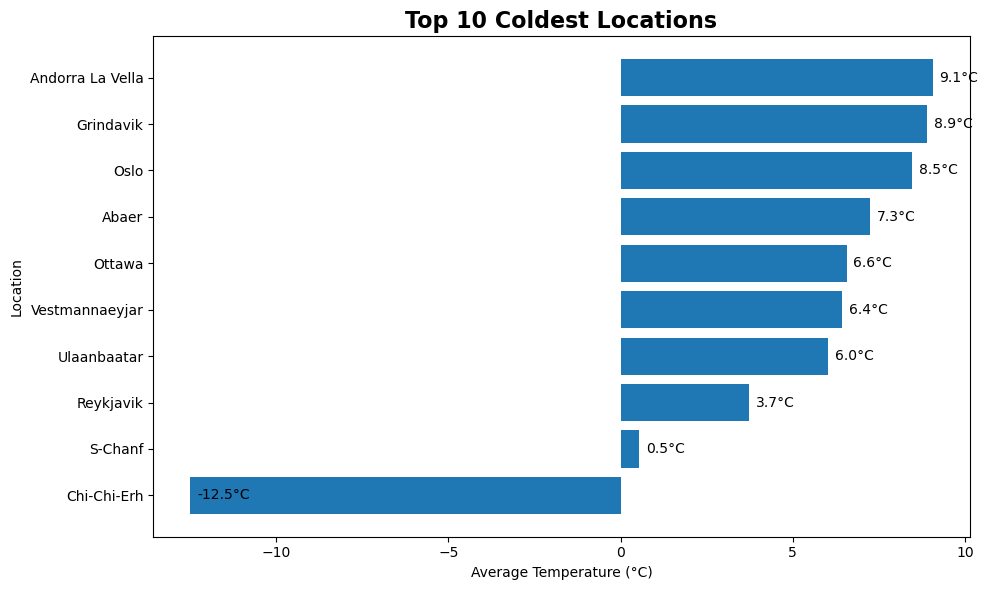

In [34]:
# Calculate average temperature
coldest = (
    df.groupby("location_name")["temperature_celsius"]
    .mean()
    .sort_values()
    .head(10)
)

plt.figure(figsize=(10, 6))

bars = plt.barh(
    coldest.index,
    coldest.values
)

plt.title("Top 10 Coldest Locations", fontsize=16, fontweight="bold")
plt.xlabel("Average Temperature (°C)")
plt.ylabel("Location")

for bar in bars:
    plt.text(
        bar.get_width() + 0.2,
        bar.get_y() + bar.get_height()/2,
        f"{bar.get_width():.1f}°C",
        va="center"
    )

plt.tight_layout()
plt.show()

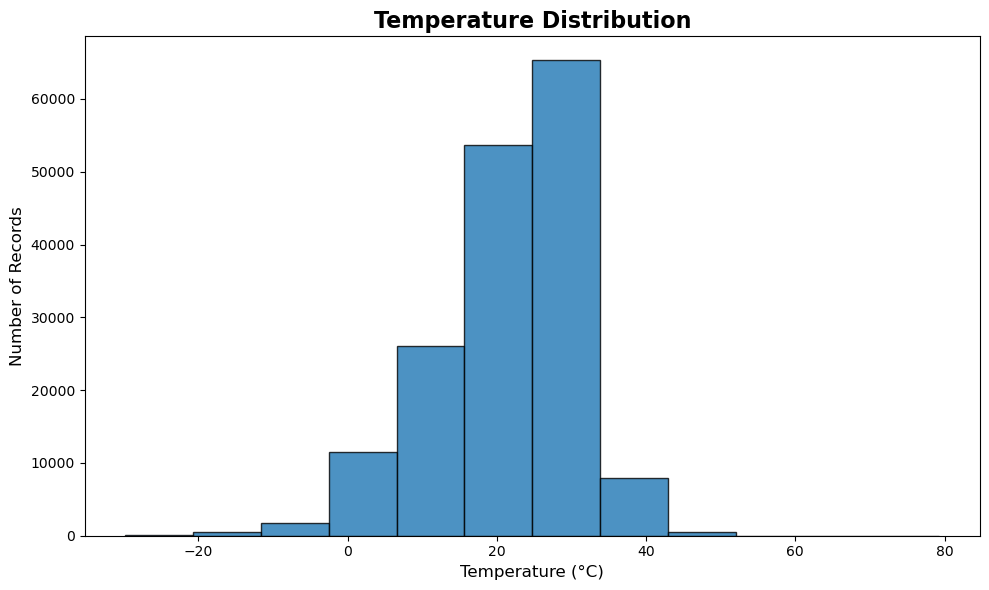

In [35]:
plt.figure(figsize=(10, 6))

plt.hist(
    df["temperature_celsius"].dropna(),
    bins=12,
    edgecolor="black",
    alpha=0.8
)

plt.title("Temperature Distribution", fontsize=16, fontweight="bold")
plt.xlabel("Temperature (°C)", fontsize=12)
plt.ylabel("Number of Records", fontsize=12)

plt.tight_layout()
plt.show()

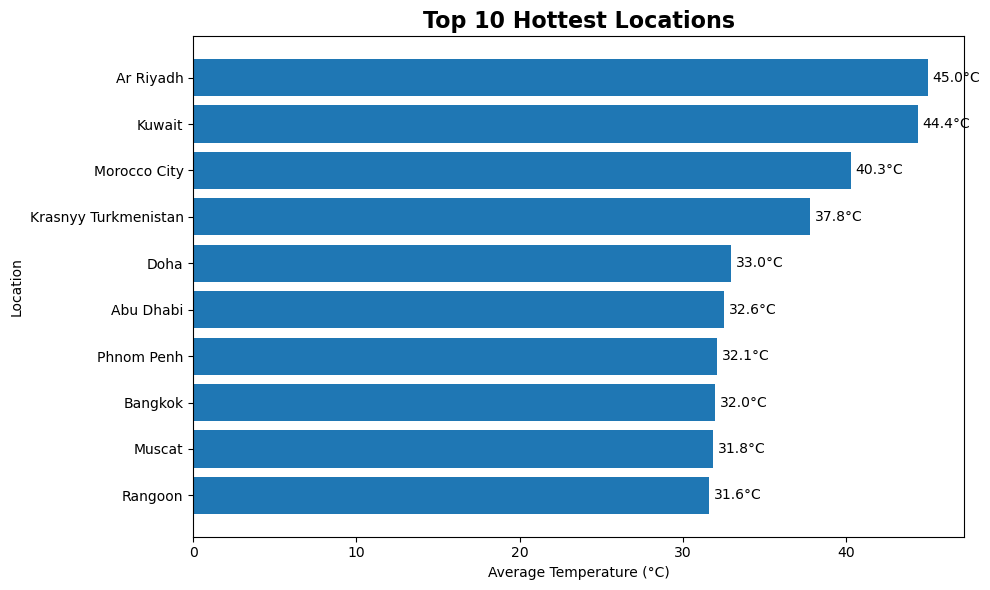

In [36]:
hot = (
    df.groupby("location_name")["temperature_celsius"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
    .sort_values()
)

plt.figure(figsize=(10, 6))

bars = plt.barh(hot.index, hot.values)

plt.title("Top 10 Hottest Locations", fontsize=16, fontweight="bold")
plt.xlabel("Average Temperature (°C)")
plt.ylabel("Location")

for bar in bars:
    plt.text(
        bar.get_width() + 0.3,
        bar.get_y() + bar.get_height() / 2,
        f"{bar.get_width():.1f}°C",
        va="center"
    )

plt.tight_layout()
plt.show()

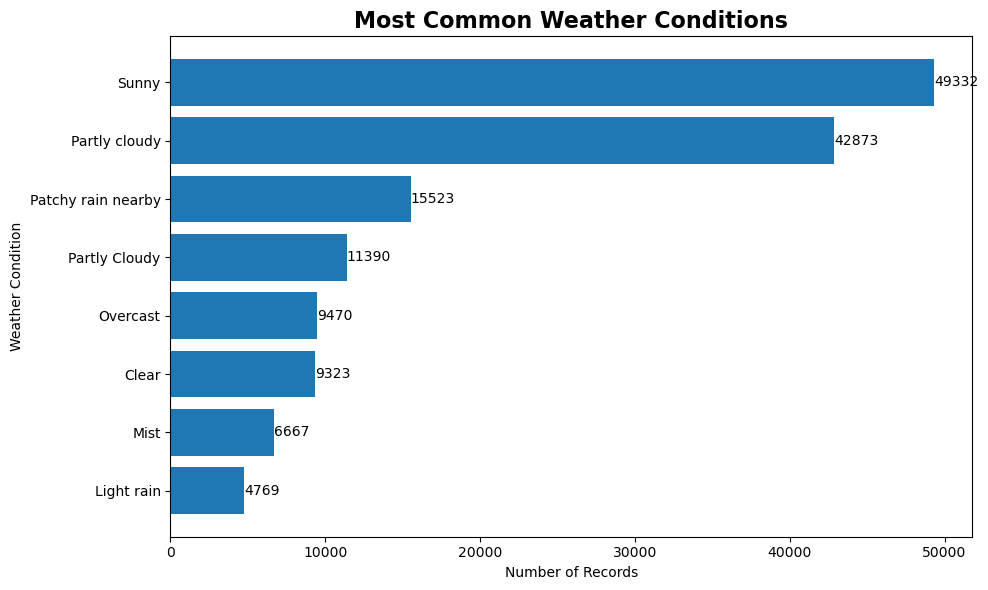

In [37]:
conditions = df["condition_text"].value_counts().head(8)

plt.figure(figsize=(10, 6))

bars = plt.barh(
    conditions.index[::-1],
    conditions.values[::-1]
)

plt.title("Most Common Weather Conditions", fontsize=16, fontweight="bold")
plt.xlabel("Number of Records")
plt.ylabel("Weather Condition")

for bar in bars:
    plt.text(
        bar.get_width() + 10,
        bar.get_y() + bar.get_height() / 2,
        f"{int(bar.get_width())}",
        va="center"
    )

plt.tight_layout()
plt.show()

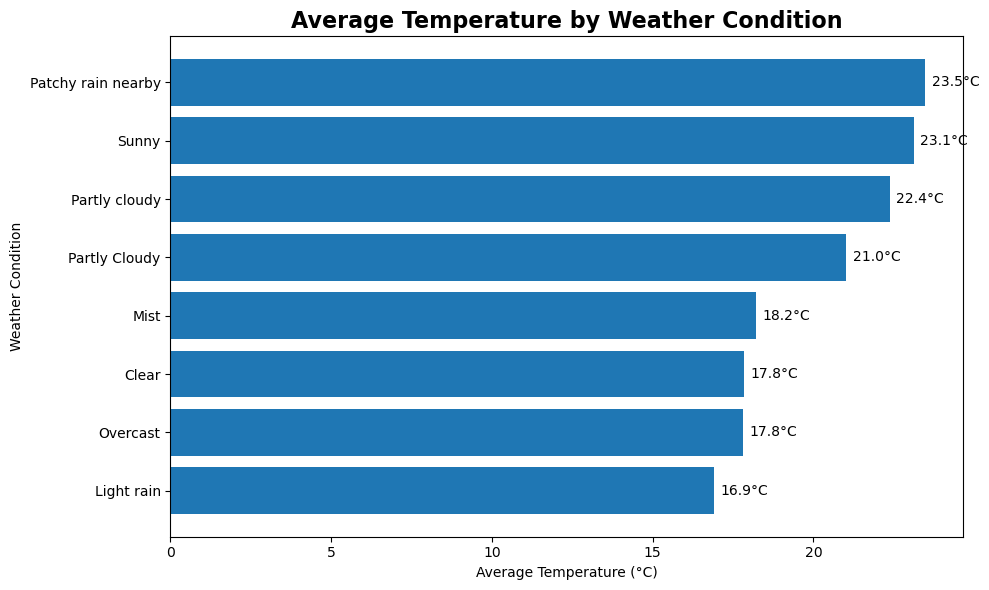

In [38]:
top_conditions = df["condition_text"].value_counts().head(8).index

condition_temp = (
    df[df["condition_text"].isin(top_conditions)]
    .groupby("condition_text")["temperature_celsius"]
    .mean()
    .sort_values()
)

plt.figure(figsize=(10, 6))

bars = plt.barh(
    condition_temp.index,
    condition_temp.values
)

plt.title(
    "Average Temperature by Weather Condition",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Average Temperature (°C)")
plt.ylabel("Weather Condition")

for bar in bars:
    plt.text(
        bar.get_width() + 0.2,
        bar.get_y() + bar.get_height() / 2,
        f"{bar.get_width():.1f}°C",
        va="center"
    )

plt.tight_layout()
plt.show()

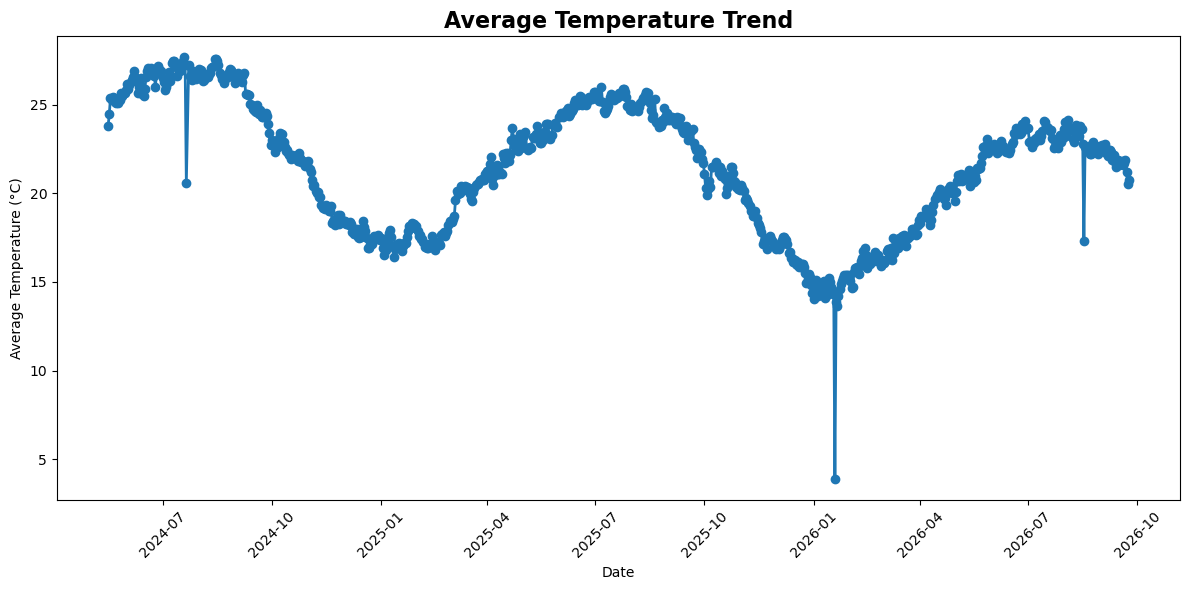

In [42]:
# Convert date column
df["last_updated"] = pd.to_datetime(
    df["last_updated"],
    errors="coerce"
)

# Sort by date
temp_trend = (
    df.groupby(df["last_updated"].dt.date)["temperature_celsius"]
    .mean()
)

plt.figure(figsize=(12, 6))

plt.plot(
    temp_trend.index,
    temp_trend.values,
    marker="o",
    linewidth=2
)

plt.title(
    "Average Temperature Trend",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Date")
plt.ylabel("Average Temperature (°C)")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

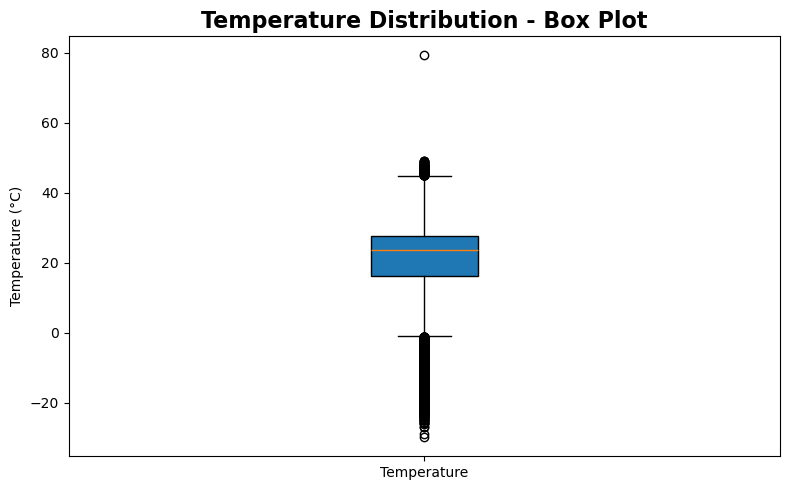

In [40]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.boxplot(
    df["temperature_celsius"].dropna(),
    patch_artist=True
)

plt.title("Temperature Distribution - Box Plot", fontsize=16, fontweight="bold")
plt.ylabel("Temperature (°C)")
plt.xticks([1], ["Temperature"])

plt.tight_layout()
plt.show()

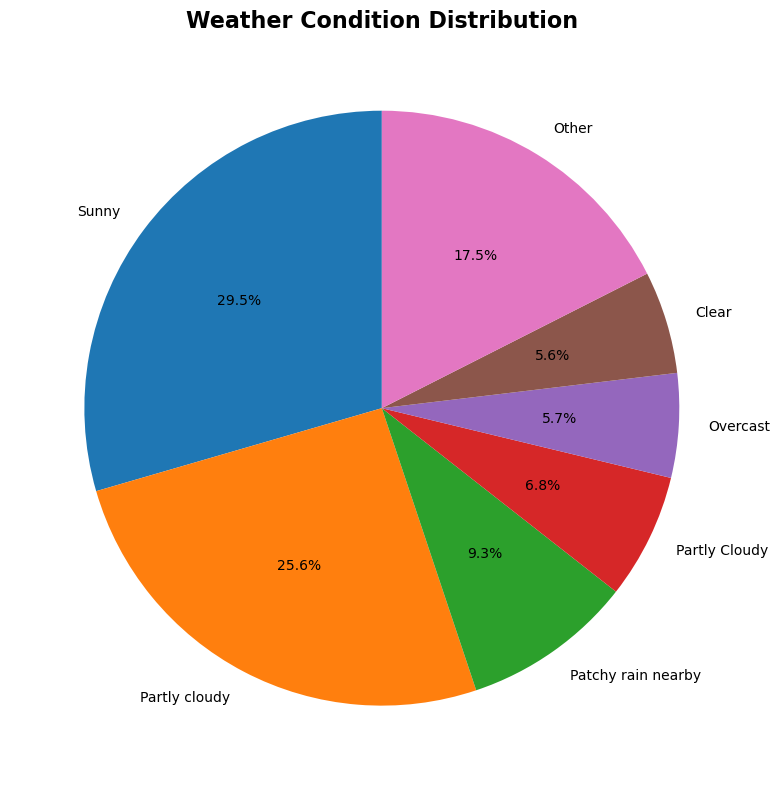

In [43]:
conditions = df["condition_text"].value_counts()

top_6 = conditions.head(6)

other = conditions.iloc[6:].sum()

pie_data = top_6.copy()

if other > 0:
    pie_data["Other"] = other

plt.figure(figsize=(8, 8))

plt.pie(
    pie_data.values,
    labels=pie_data.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title(
    "Weather Condition Distribution",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()
plt.show()